#  Movie Rental Data Warehouse
### Sakila OLTP → `sakila_dw` — ETL Pipeline & Business Analytics

**Course:** Data Warehousing / Data Architecture  
**Pipeline Steps:**
1. [Configuration & Connection](#1.-Configuration-&-Connection)
2. [ETL: Load Dimension Tables](#2.-ETL:-Load-Dimension-Tables)
3. [ETL: Load Fact Tables](#3.-ETL:-Load-Fact-Tables)
4. [Data Quality Checks](#4.-Data-Quality-Checks)
5. [Business Question Analytics](#5.-Business-Question-Analytics)


---
## 1. Configuration & Connection


In [1]:
import mysql.connector
import pandas as pd
from datetime import date, timedelta
from IPython.display import display

# ── Database credentials ───────────────────────────────────────────
DB_HOST     = "localhost"
DB_USER     = "root"
DB_PASSWORD = ""          # XAMPP default
DB_PORT     = 3306

SOURCE_DB   = "sakila"     # OLTP source
TARGET_DB   = "sakila_dw"  # Data Warehouse target

# ── Date range for dim_date ────────────────────────────────────────
DIM_DATE_START = date(2005, 1, 1)
DIM_DATE_END   = date(2007, 12, 31)

print(" Configuration loaded.")

 Configuration loaded.


In [2]:
# ── Connection helpers ─────────────────────────────────────────────

def get_connection(database=None):
    """Return a new MySQL connection, optionally selecting a database."""
    cfg = dict(host=DB_HOST, user=DB_USER,
               password=DB_PASSWORD, port=DB_PORT)
    if database:
        cfg["database"] = database
    return mysql.connector.connect(**cfg)


def section(title):
    """Print a section separator."""
    bar = "=" * 60
    print(f"\n{bar}\n  {title}\n{bar}")


def execute_many(cursor, sql, rows, table_name):
    """Bulk-insert rows with progress output."""
    if not rows:
        print(f"  [SKIP] {table_name}: no rows to insert.")
        return
    cursor.executemany(sql, rows)
    print(f"  [OK]   {table_name}: {cursor.rowcount} rows inserted.")


# ── Test connections ───────────────────────────────────────────────
try:
    src_conn = get_connection(SOURCE_DB)
    dw_conn  = get_connection(TARGET_DB)
    src_cursor = src_conn.cursor()
    dw_cursor  = dw_conn.cursor()
    print(" Connected to sakila        (source OLTP)")
    print(" Connected to sakila_dw     (target DW)")
except mysql.connector.Error as e:
    print(f"\n Connection failed: {e}")
    raise

 Connected to sakila        (source OLTP)
 Connected to sakila_dw     (target DW)


---
## 2. ETL: Load Dimension Tables

Load order: `dim_date` → `dim_customer` → `dim_film` → `dim_store` → `dim_staff`

In [3]:
# ── 2.1 dim_date ───────────────────────────────────────────────────
# Covers the full Sakila rental period (2005-01-01 → 2007-12-31).

section("Loading dim_date")

rows = []
d = DIM_DATE_START
while d <= DIM_DATE_END:
    dow = d.isoweekday()   # 1=Mon … 7=Sun
    rows.append((
        int(d.strftime("%Y%m%d")),   # date_key
        d,                            # full_date
        dow,                          # day_of_week
        d.strftime("%A"),             # day_name
        d.day,                        # day_of_month
        d.timetuple().tm_yday,        # day_of_year
        int(d.strftime("%W")),        # week_of_year  (Mon-based)
        d.month,                      # month_number
        d.strftime("%B"),             # month_name
        (d.month - 1) // 3 + 1,      # quarter
        d.year,                       # year
        1 if dow >= 6 else 0          # is_weekend
    ))
    d += timedelta(days=1)

sql = """
    INSERT IGNORE INTO dim_date
        (date_key, full_date, day_of_week, day_name,
         day_of_month, day_of_year, week_of_year,
         month_number, month_name, quarter, year, is_weekend)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "dim_date")
dw_conn.commit()


  Loading dim_date
  [OK]   dim_date: 1095 rows inserted.


In [4]:
# ── 2.2 dim_customer ───────────────────────────────────────────────
# Source tables: customer + address + city + country
# Transforms: full name concat, flat address hierarchy

section("Loading dim_customer")

src_cursor.execute("""
    SELECT
        c.customer_id,
        CONCAT(c.first_name, ' ', c.last_name)  AS full_name,
        c.email,
        a.address,
        a.district,
        ci.city,
        co.country,
        a.postal_code,
        a.phone,
        c.active                                 AS is_active,
        DATE(c.create_date)                      AS create_date
    FROM   customer c
    JOIN   address  a  ON c.address_id  = a.address_id
    JOIN   city     ci ON a.city_id     = ci.city_id
    JOIN   country  co ON ci.country_id = co.country_id
    ORDER  BY c.customer_id
""")
rows = src_cursor.fetchall()

sql = """
    INSERT IGNORE INTO dim_customer
        (customer_id, full_name, email, address, district,
         city, country, postal_code, phone, is_active, create_date)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "dim_customer")
dw_conn.commit()


  Loading dim_customer
  [OK]   dim_customer: 599 rows inserted.


In [5]:
# ── 2.3 dim_film ───────────────────────────────────────────────────
# Source tables: film + language + film_category + category
# Transform: resolves many-to-many film↔category by picking the
#            alphabetically-first category per film (ROW_NUMBER trick).
# NOTE: A full design could use a separate bridge table for
#       film-category and film-actor many-to-many relationships.

section("Loading dim_film")

src_cursor.execute("""
    SELECT
        f.film_id,
        f.title,
        f.description,
        f.release_year,
        l.name                                         AS language,
        f.rental_duration,
        f.rental_rate,
        f.length                                       AS film_length_min,
        f.replacement_cost,
        f.rating,
        f.special_features,
        cat.name                                       AS category
    FROM film f
    JOIN language l ON f.language_id = l.language_id
    LEFT JOIN (
        SELECT fc.film_id, c.name,
               ROW_NUMBER() OVER (PARTITION BY fc.film_id ORDER BY c.name) AS rn
        FROM   film_category fc
        JOIN   category      c ON fc.category_id = c.category_id
    ) cat ON cat.film_id = f.film_id AND cat.rn = 1
    ORDER BY f.film_id
""")
raw_rows = src_cursor.fetchall()

rows = []
for row in raw_rows:
    row = list(row)
    if isinstance(row[10], set):
        row[10] = ', '.join(sorted(row[10]))
    rows.append(tuple(row))

sql = """
    INSERT IGNORE INTO dim_film
        (film_id, title, description, release_year, language,
         rental_duration, rental_rate, film_length_min,
         replacement_cost, rating, special_features, category)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "dim_film")
dw_conn.commit()


  Loading dim_film
  [OK]   dim_film: 1000 rows inserted.


In [6]:
# ── 2.4 dim_store ──────────────────────────────────────────────────
# Source tables: store + staff (manager lookup) + address + city + country

section("Loading dim_store")

src_cursor.execute("""
    SELECT
        s.store_id,
        CONCAT(st.first_name, ' ', st.last_name)  AS manager_full_name,
        a.address,
        a.district,
        ci.city,
        co.country,
        a.postal_code,
        a.phone
    FROM  store   s
    JOIN  staff   st ON s.manager_staff_id = st.staff_id
    JOIN  address  a ON s.address_id       = a.address_id
    JOIN  city    ci ON a.city_id          = ci.city_id
    JOIN  country co ON ci.country_id      = co.country_id
    ORDER BY s.store_id
""")
rows = src_cursor.fetchall()

sql = """
    INSERT IGNORE INTO dim_store
        (store_id, manager_full_name, address, district,
         city, country, postal_code, phone)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "dim_store")
dw_conn.commit()


  Loading dim_store
  [OK]   dim_store: 2 rows inserted.


In [7]:
# ── 2.5 dim_staff ──────────────────────────────────────────────────
# Source table: staff

section("Loading dim_staff")

src_cursor.execute("""
    SELECT
        staff_id,
        CONCAT(first_name, ' ', last_name)  AS full_name,
        email,
        store_id,
        active                               AS is_active
    FROM  staff
    ORDER BY staff_id
""")
rows = src_cursor.fetchall()

sql = """
    INSERT IGNORE INTO dim_staff
        (staff_id, full_name, email, store_id, is_active)
    VALUES (%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "dim_staff")
dw_conn.commit()


  Loading dim_staff
  [OK]   dim_staff: 2 rows inserted.


---
## 3. ETL: Load Fact Tables
Fact tables are loaded **after** all dimensions.  
Surrogate key lookups (`natural_id → surrogate_key`) are built in-memory for performance.

In [8]:
# ── 3.1 fact_rental ────────────────────────────────────────────────
# Source tables: rental + inventory + film
# Measures computed:
#   • rental_duration_days  — actual days film was kept
#   • expected_duration_days — policy limit from film.rental_duration
#   • is_late_return         — 1 if actual > expected
#   • days_late              — difference (negative = returned early)
# Rows with missing surrogate keys are skipped and warned.

section("Loading fact_rental")

src_cursor.execute("""
    SELECT
        r.rental_id,
        r.rental_date,
        r.return_date,
        r.customer_id,
        i.film_id,
        i.store_id,
        r.staff_id,
        f.rental_duration          AS expected_duration_days
    FROM   rental    r
    JOIN   inventory i ON r.inventory_id = i.inventory_id
    JOIN   film      f ON i.film_id      = f.film_id
    ORDER  BY r.rental_id
""")
rentals = src_cursor.fetchall()

# Build surrogate-key lookup maps
dw_cursor.execute("SELECT customer_id, customer_key FROM dim_customer")
cust_map  = {r[0]: r[1] for r in dw_cursor.fetchall()}

dw_cursor.execute("SELECT film_id, film_key FROM dim_film")
film_map  = {r[0]: r[1] for r in dw_cursor.fetchall()}

dw_cursor.execute("SELECT store_id, store_key FROM dim_store")
store_map = {r[0]: r[1] for r in dw_cursor.fetchall()}

dw_cursor.execute("SELECT staff_id, staff_key FROM dim_staff")
staff_map = {r[0]: r[1] for r in dw_cursor.fetchall()}

rows    = []
skipped = 0

for (rental_id, rental_date, return_date, customer_id,
     film_id, store_id, staff_id, expected_days) in rentals:

    rental_date_key = int(rental_date.strftime("%Y%m%d"))
    return_date_key = int(return_date.strftime("%Y%m%d")) if return_date else None

    if return_date:
        actual_days = (return_date.date() - rental_date.date()).days
        is_late     = 1 if actual_days > expected_days else 0
        days_late   = actual_days - expected_days
    else:
        actual_days = is_late = days_late = None

    ck = cust_map.get(customer_id)
    fk = film_map.get(film_id)
    sk = store_map.get(store_id)
    stk = staff_map.get(staff_id)

    if None in (ck, fk, sk, stk):
        skipped += 1
        continue

    rows.append((
        rental_id, rental_date_key, return_date_key,
        ck, fk, sk, stk,
        actual_days, expected_days,
        is_late, days_late, 1
    ))

if skipped:
    print(f"  [WARN] {skipped} rental rows skipped due to missing surrogate keys.")

sql = """
    INSERT IGNORE INTO fact_rental
        (rental_id, rental_date_key, return_date_key,
         customer_key, film_key, store_key, staff_key,
         rental_duration_days, expected_duration_days,
         is_late_return, days_late, rental_count)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "fact_rental")
dw_conn.commit()


  Loading fact_rental
  [OK]   fact_rental: 16044 rows inserted.


In [9]:
# ── 3.2 fact_payment ───────────────────────────────────────────────
# Source tables: payment + rental + inventory (to resolve film/store)
# film_key and store_key are nullable — some payments may lack context.

section("Loading fact_payment")

src_cursor.execute("""
    SELECT
        p.payment_id,
        p.payment_date,
        p.customer_id,
        p.staff_id,
        p.rental_id,
        i.film_id,
        i.store_id,
        p.amount
    FROM  payment   p
    LEFT JOIN rental    r ON p.rental_id    = r.rental_id
    LEFT JOIN inventory i ON r.inventory_id = i.inventory_id
    ORDER BY p.payment_id
""")
payments = src_cursor.fetchall()

# Reuse surrogate-key maps (already built above)
dw_cursor.execute("SELECT customer_id, customer_key FROM dim_customer")
cust_map  = {r[0]: r[1] for r in dw_cursor.fetchall()}
dw_cursor.execute("SELECT staff_id, staff_key FROM dim_staff")
staff_map = {r[0]: r[1] for r in dw_cursor.fetchall()}
dw_cursor.execute("SELECT film_id, film_key FROM dim_film")
film_map  = {r[0]: r[1] for r in dw_cursor.fetchall()}
dw_cursor.execute("SELECT store_id, store_key FROM dim_store")
store_map = {r[0]: r[1] for r in dw_cursor.fetchall()}

rows    = []
skipped = 0

for (payment_id, payment_date, customer_id, staff_id,
     rental_id, film_id, store_id, amount) in payments:

    ck  = cust_map.get(customer_id)
    stk = staff_map.get(staff_id)

    if None in (ck, stk):
        skipped += 1
        continue

    rows.append((
        payment_id,
        int(payment_date.strftime("%Y%m%d")),
        ck, stk,
        rental_id,
        film_map.get(film_id)   if film_id  else None,
        store_map.get(store_id) if store_id else None,
        float(amount),
        1
    ))

if skipped:
    print(f"  [WARN] {skipped} payment rows skipped.")

sql = """
    INSERT IGNORE INTO fact_payment
        (payment_id, payment_date_key, customer_key, staff_key,
         rental_id, film_key, store_key, payment_amount, payment_count)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s)
"""
execute_many(dw_cursor, sql, rows, "fact_payment")
dw_conn.commit()


  Loading fact_payment
  [OK]   fact_payment: 16044 rows inserted.


---
## 4. Data Quality Checks
Seven checks validate the loaded data warehouse against the OLTP source.

In [10]:
section("Data Quality Report")

# ── Row-count parity checks ────────────────────────────────────────
parity_checks = [
    ("QC-1  fact_rental  vs sakila.rental",
     "SELECT COUNT(*) FROM fact_rental",
     "SELECT COUNT(*) FROM rental"),
    ("QC-2  fact_payment vs sakila.payment",
     "SELECT COUNT(*) FROM fact_payment",
     "SELECT COUNT(*) FROM payment"),
]

for label, dw_sql, src_sql in parity_checks:
    dw_cursor.execute(dw_sql);  dw_n  = dw_cursor.fetchone()[0]
    src_cursor.execute(src_sql); src_n = src_cursor.fetchone()[0]
    status = " PASS" if dw_n == src_n else "❌ FAIL"
    print(f"  [{status}] {label}: OLTP={src_n}, DW={dw_n}")

# ── Single-table anomaly checks ────────────────────────────────────
anomaly_checks = [
    ("QC-3  Negative rental durations",
     "SELECT COUNT(*) FROM fact_rental WHERE rental_duration_days < 0"),
    ("QC-4  Payment amount <= 0",
     "SELECT COUNT(*) FROM fact_payment WHERE payment_amount <= 0"),
    ("QC-5  Extreme rentals > 365 days",
     "SELECT COUNT(*) FROM fact_rental WHERE rental_duration_days > 365"),
    ("QC-6  Rentals with NULL film_key",
     "SELECT COUNT(*) FROM fact_rental WHERE film_key IS NULL"),
    ("QC-7  Orphan rental_date_key (not in dim_date)",
     """SELECT COUNT(*) FROM fact_rental fr
        LEFT JOIN dim_date d ON fr.rental_date_key = d.date_key
        WHERE d.date_key IS NULL"""),
]

for label, sql in anomaly_checks:
    dw_cursor.execute(sql)
    n      = dw_cursor.fetchone()[0]
    status = " PASS" if n == 0 else "⚠️  WARN"
    print(f"  [{status}] {label}: {n} issues")

# ── Row counts summary ─────────────────────────────────────────────
print("\n  Table Row Counts:")
tables = ["dim_date", "dim_customer", "dim_film",
          "dim_store", "dim_staff", "fact_rental", "fact_payment"]
for t in tables:
    dw_cursor.execute(f"SELECT COUNT(*) FROM {t}")
    print(f"    {t:<22} {dw_cursor.fetchone()[0]:>6} rows")


  Data Quality Report
  [ PASS] QC-1  fact_rental  vs sakila.rental: OLTP=16044, DW=16044
  [ PASS] QC-2  fact_payment vs sakila.payment: OLTP=16044, DW=16044
  [ PASS] QC-3  Negative rental durations: 0 issues
  [⚠️  WARN] QC-4  Payment amount <= 0: 24 issues
  [ PASS] QC-5  Extreme rentals > 365 days: 0 issues
  [ PASS] QC-6  Rentals with NULL film_key: 0 issues
  [ PASS] QC-7  Orphan rental_date_key (not in dim_date): 0 issues

  Table Row Counts:
    dim_date                 1095 rows
    dim_customer              599 rows
    dim_film                 1000 rows
    dim_store                   2 rows
    dim_staff                   2 rows
    fact_rental             16044 rows
    fact_payment            16044 rows


---
## 5. Business Question Analytics
Results are displayed as **pandas DataFrames** for readability and easy export.

| BQ | Question |
|---|---|
| BQ-1 | Top 10 most-rented films |
| BQ-2 | Top 10 films by revenue |
| BQ-3 | Film categories by popularity & revenue |
| BQ-4 | Store performance (rentals & revenue) |
| BQ-5 | Top 10 customers by rentals & revenue |
| BQ-6 | Monthly rental activity & revenue |
| BQ-7 | Staff performance |
| BQ-8 | Top 10 cities by customer activity |
| BQ-9 | Average rental duration by category |
| BQ-10 | Top 10 films returned late most often |
| BQ-11 | Quarterly revenue trend |

In [11]:
# ── Query helper ───────────────────────────────────────────────────

def run_bq(title, sql, limit=None):
    """Execute a business-question SQL and display as a DataFrame."""
    dw_cursor.execute(sql)
    rows = dw_cursor.fetchall()
    cols = [d[0] for d in dw_cursor.description]
    df   = pd.DataFrame(rows, columns=cols)
    if limit:
        df = df.head(limit)
    print(f"\n{'='*65}\n  {title}\n{'='*65}")
    display(df)
    return df

print(" Query helper ready.")

 Query helper ready.


In [12]:
# BQ-1: Which films are rented most frequently?

bq1 = run_bq("BQ-1: Top 10 Most Frequently Rented Films", """
    SELECT f.title, f.category,
           SUM(r.rental_count) AS total_rentals
    FROM   fact_rental r
    JOIN   dim_film    f ON r.film_key = f.film_key
    GROUP  BY f.film_key, f.title, f.category
    ORDER  BY total_rentals DESC
    LIMIT 10
""")


  BQ-1: Top 10 Most Frequently Rented Films


,title,category,total_rentals
0,BUCKET BROTHERHOOD,Travel,34
1,ROCKETEER MOTHER,Foreign,33
2,JUGGLER HARDLY,Animation,32
3,RIDGEMONT SUBMARINE,New,32
4,SCALAWAG DUCK,Music,32
5,GRIT CLOCKWORK,Games,32
6,FORWARD TEMPLE,Games,32
7,RUSH GOODFELLAS,Family,31
8,TIMBERLAND SKY,Classics,31
9,ZORRO ARK,Comedy,31


In [13]:
# BQ-2: Which films generate the highest revenue?

bq2 = run_bq("BQ-2: Top 10 Films by Revenue", """
    SELECT f.title, f.category,
           ROUND(SUM(p.payment_amount), 2) AS total_revenue
    FROM   fact_payment p
    JOIN   dim_film     f ON p.film_key = f.film_key
    WHERE  p.film_key IS NOT NULL
    GROUP  BY f.film_key, f.title, f.category
    ORDER  BY total_revenue DESC
    LIMIT 10
""")


  BQ-2: Top 10 Films by Revenue


,title,category,total_revenue
0,TELEGRAPH VOYAGE,Music,231.73
1,WIFE TURN,Documentary,223.69
2,ZORRO ARK,Comedy,214.69
3,GOODFELLAS SALUTE,Sci-Fi,209.69
4,SATURDAY LAMBS,Sports,204.72
5,TITANS JERK,Sci-Fi,201.71
6,TORQUE BOUND,Drama,198.72
7,HARRY IDAHO,Drama,195.70
8,INNOCENT USUAL,Foreign,191.74
9,HUSTLER PARTY,Comedy,190.78


In [14]:
# BQ-3: Which film categories are most popular?

bq3 = run_bq("BQ-3: Film Categories by Popularity & Revenue", """
    SELECT f.category,
           SUM(r.rental_count)              AS total_rentals,
           ROUND(SUM(p.payment_amount), 2)  AS total_revenue
    FROM   fact_rental   r
    JOIN   dim_film      f  ON r.film_key  = f.film_key
    LEFT JOIN fact_payment p ON r.rental_id = p.rental_id
    GROUP  BY f.category
    ORDER  BY total_rentals DESC
""")


  BQ-3: Film Categories by Popularity & Revenue


,category,total_rentals,total_revenue
0,Sports,1179,5314.21
1,Animation,1166,4656.30
2,Action,1112,4375.85
3,Sci-Fi,1101,4756.98
4,Family,1096,4226.07
5,Drama,1060,4587.39
6,Documentary,1050,4217.52
7,Foreign,1033,4270.67
8,Games,969,4281.33
9,Children,945,3655.55


In [15]:
# BQ-4: Which stores generate the highest rentals and revenue?

bq4 = run_bq("BQ-4: Store Performance (Rentals & Revenue)", """
    SELECT s.store_id, s.city, s.country,
           SUM(r.rental_count)              AS total_rentals,
           ROUND(SUM(p.payment_amount), 2)  AS total_revenue
    FROM   fact_rental   r
    JOIN   dim_store     s  ON r.store_key  = s.store_key
    LEFT JOIN fact_payment p ON r.rental_id  = p.rental_id
    GROUP  BY s.store_key, s.store_id, s.city, s.country
    ORDER  BY total_revenue DESC
""")


  BQ-4: Store Performance (Rentals & Revenue)


,store_id,city,country,total_rentals,total_revenue
0,2,Woodridge,Australia,8121,33726.77
1,1,Lethbridge,Canada,7923,33679.79


In [16]:
# BQ-5: Which customers rent the most and generate the highest revenue?

bq5 = run_bq("BQ-5: Top 10 Customers by Rentals & Revenue", """
    SELECT c.full_name, c.city, c.country,
           SUM(r.rental_count)              AS total_rentals,
           ROUND(SUM(p.payment_amount), 2)  AS total_revenue
    FROM   fact_rental   r
    JOIN   dim_customer  c  ON r.customer_key = c.customer_key
    LEFT JOIN fact_payment p ON r.rental_id   = p.rental_id
    GROUP  BY c.customer_key, c.full_name, c.city, c.country
    ORDER  BY total_rentals DESC
    LIMIT 10
""")


  BQ-5: Top 10 Customers by Rentals & Revenue


,full_name,city,country,total_rentals,total_revenue
0,ELEANOR HUNT,Saint-Denis,Réunion,46,216.54
1,KARL SEAL,Cape Coral,United States,45,221.55
2,CLARA SHAW,Molodetšno,Belarus,42,195.58
3,MARCIA DEAN,Tanza,Philippines,42,175.58
4,TAMMY SANDERS,Changhwa,Taiwan,41,155.59
5,SUE PETERS,Changzhou,China,40,154.60
6,WESLEY BULL,Ourense (Orense),Spain,40,177.60
7,RHONDA KENNEDY,Apeldoorn,Netherlands,39,194.61
8,MARION SNYDER,Santa Brbara dOeste,Brazil,39,194.61
9,TIM CARY,Bijapur,India,39,175.61


In [17]:
# BQ-6: How does rental activity change by month?

bq6 = run_bq("BQ-6: Monthly Rental Activity & Revenue", """
    SELECT d.year, d.month_name, d.month_number,
           SUM(r.rental_count)              AS total_rentals,
           ROUND(SUM(p.payment_amount), 2)  AS total_revenue
    FROM   fact_rental   r
    JOIN   dim_date      d  ON r.rental_date_key = d.date_key
    LEFT JOIN fact_payment p ON r.rental_id      = p.rental_id
    GROUP  BY d.year, d.month_number, d.month_name
    ORDER  BY d.year, d.month_number
""")


  BQ-6: Monthly Rental Activity & Revenue


,year,month_name,month_number,total_rentals,total_revenue
0,2005,May,5,1156,4823.44
1,2005,June,6,2311,9629.89
2,2005,July,7,6709,28368.91
3,2005,August,8,5686,24070.14
4,2006,February,2,182,514.18


In [18]:
# BQ-7: Which staff process the most rentals and collect the most revenue?

bq7 = run_bq("BQ-7: Staff Performance", """
    SELECT st.full_name,
           SUM(r.rental_count)              AS rentals_processed,
           ROUND(SUM(p.payment_amount), 2)  AS payments_collected
    FROM   fact_rental   r
    JOIN   dim_staff     st ON r.staff_key  = st.staff_key
    LEFT JOIN fact_payment p ON r.rental_id = p.rental_id
    GROUP  BY st.staff_key, st.full_name
    ORDER  BY rentals_processed DESC
""")


  BQ-7: Staff Performance


,full_name,rentals_processed,payments_collected
0,Mike Hillyer,8040,33524.62
1,Jon Stephens,8004,33881.94


In [19]:
# BQ-8: Which cities/countries have the most active customers?

bq8 = run_bq("BQ-8: Top 10 Cities by Customer Activity", """
    SELECT c.country, c.city,
           COUNT(DISTINCT r.customer_key)  AS unique_customers,
           SUM(r.rental_count)             AS total_rentals
    FROM   fact_rental  r
    JOIN   dim_customer c ON r.customer_key = c.customer_key
    GROUP  BY c.country, c.city
    ORDER  BY total_rentals DESC
    LIMIT 10
""")


  BQ-8: Top 10 Cities by Customer Activity


,country,city,unique_customers,total_rentals
0,United States,Aurora,2,50
1,United Kingdom,London,2,48
2,Réunion,Saint-Denis,1,46
3,United States,Cape Coral,1,45
4,Philippines,Tanza,1,42
5,Belarus,Molodetšno,1,42
6,Taiwan,Changhwa,1,41
7,China,Changzhou,1,40
8,Spain,Ourense (Orense),1,40
9,Netherlands,Apeldoorn,1,39


In [20]:
# BQ-9: What is the average rental duration per category?

bq9 = run_bq("BQ-9: Avg Rental Duration by Category", """
    SELECT f.category,
           ROUND(AVG(r.rental_duration_days),  2) AS avg_actual_days,
           ROUND(AVG(r.expected_duration_days), 2) AS avg_allowed_days
    FROM   fact_rental r
    JOIN   dim_film    f ON r.film_key = f.film_key
    WHERE  r.rental_duration_days IS NOT NULL
    GROUP  BY f.category
    ORDER  BY avg_actual_days DESC
""")


  BQ-9: Avg Rental Duration by Category


,category,avg_actual_days,avg_allowed_days
0,Sports,5.20,4.74
1,Games,5.20,5.01
2,Comedy,5.15,4.80
3,Music,5.07,5.26
4,Sci-Fi,5.06,4.78
5,Documentary,5.06,4.65
6,Horror,5.05,4.93
7,Family,5.05,5.16
8,Foreign,5.04,5.11
9,Action,5.03,4.94


In [21]:
# BQ-10: Which films are returned late most often?

bq10 = run_bq("BQ-10: Top 10 Films Returned Late Most Often", """
    SELECT f.title, f.category,
           SUM(r.rental_count)                                    AS total_rentals,
           SUM(CASE WHEN r.is_late_return = 1 THEN 1 ELSE 0 END) AS late_returns,
           ROUND(
               100.0 * SUM(CASE WHEN r.is_late_return = 1 THEN 1 ELSE 0 END)
                     / NULLIF(SUM(r.rental_count), 0), 1
           )                                                      AS late_pct
    FROM   fact_rental r
    JOIN   dim_film    f ON r.film_key = f.film_key
    WHERE  r.return_date_key IS NOT NULL
    GROUP  BY f.film_key, f.title, f.category
    ORDER  BY late_returns DESC
    LIMIT 10
""")


  BQ-10: Top 10 Films Returned Late Most Often


,title,category,total_rentals,late_returns,late_pct
0,RIDGEMONT SUBMARINE,New,31,26,83.9
1,TELEGRAPH VOYAGE,Music,27,24,88.9
2,BUTTERFLY CHOCOLAT,New,30,24,80.0
3,GRIT CLOCKWORK,Games,32,23,71.9
4,ROCKETEER MOTHER,Foreign,33,22,66.7
5,TIMBERLAND SKY,Classics,31,22,71.0
6,CHANCE RESURRECTION,Sports,27,22,81.5
7,ENGLISH BULWORTH,Sci-Fi,30,21,70.0
8,EXPENDABLE STALLION,Documentary,28,21,75.0
9,WIFE TURN,Documentary,31,21,67.7


In [22]:
# BQ-11: How does revenue trend by quarter?

bq11 = run_bq("BQ-11: Quarterly Revenue Trend", """
    SELECT d.year,
           CONCAT('Q', d.quarter)          AS quarter,
           ROUND(SUM(p.payment_amount), 2) AS quarterly_revenue
    FROM   fact_payment p
    JOIN   dim_date     d ON p.payment_date_key = d.date_key
    GROUP  BY d.year, d.quarter
    ORDER  BY d.year, d.quarter
""")

print("\n" + "="*65)
print("  GG All business questions answered ")
print("="*65)


  BQ-11: Quarterly Revenue Trend


,year,quarter,quarterly_revenue
0,2005,Q2,14453.33
1,2005,Q3,52439.05
2,2006,Q1,514.18



  GG All business questions answered 


In [23]:
# ── Close connections cleanly ──────────────────────────────────────
src_cursor.close(); src_conn.close()
dw_cursor.close();  dw_conn.close()
print(" Database connections closed")

 Database connections closed


---
## 6. Visualizations
Interactive charts built from the business-question DataFrames above.  
Run **Section 5** first so `bq1`–`bq11` are in memory.

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Consistent style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})
BLUE   = "#4C72B0"
ORANGE = "#DD8452"
GREEN  = "#55A868"
RED    = "#C44E52"
PURPLE = "#8172B2"
print("Matplotlib ready — all BQ DataFrames must be loaded (run Section 5 first).")

Matplotlib ready — all BQ DataFrames must be loaded (run Section 5 first).


### VIZ-1 · Top-10 Films — Rentals vs Revenue

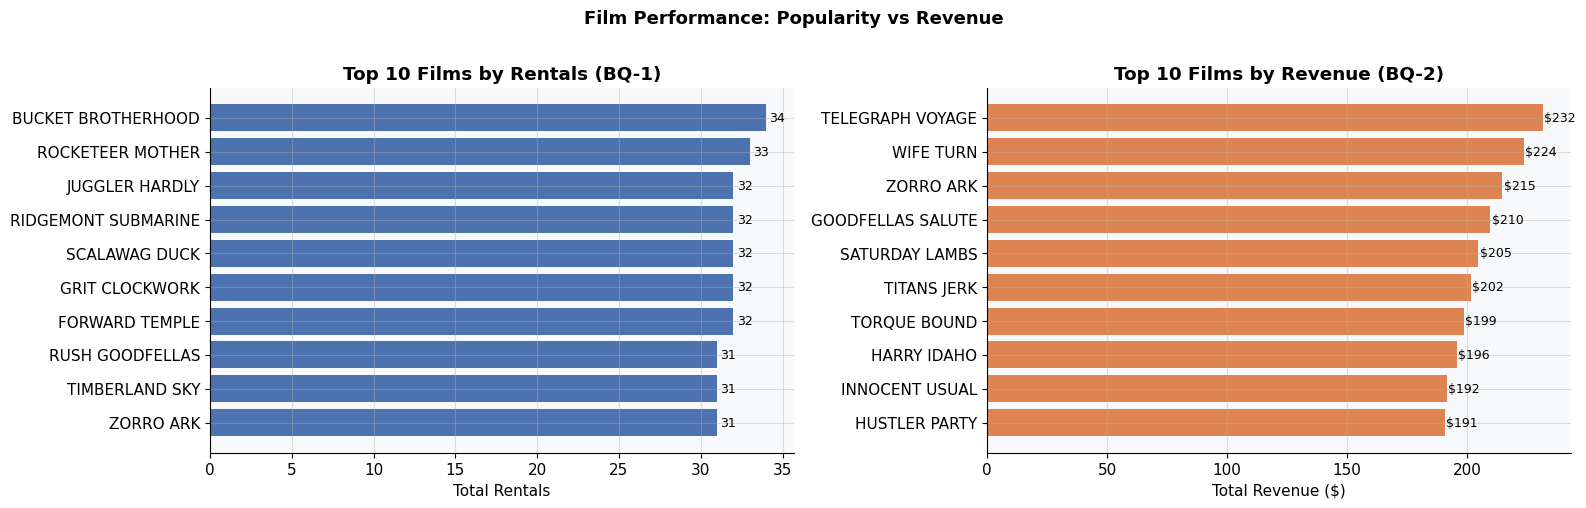

Note: Some films rank high in rentals but not revenue, and vice versa.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Convert Decimal columns to float
bq1["total_rentals"] = bq1["total_rentals"].astype(float)
bq2["total_revenue"] = bq2["total_revenue"].astype(float)

# Left: rentals
ax = axes[0]
ax.barh(
    bq1["title"][::-1],
    bq1["total_rentals"][::-1],
    color=BLUE
)

ax.set_xlabel("Total Rentals")
ax.set_title(
    "Top 10 Films by Rentals (BQ-1)",
    fontweight="bold"
)

for i, v in enumerate(bq1["total_rentals"][::-1]):
    ax.text(
        v + 0.2,
        i,
        f"{int(v)}",
        va="center",
        fontsize=9
    )

# Right: revenue
ax2 = axes[1]
ax2.barh(
    bq2["title"][::-1],
    bq2["total_revenue"][::-1],
    color=ORANGE
)

ax2.set_xlabel("Total Revenue ($)")
ax2.set_title(
    "Top 10 Films by Revenue (BQ-2)",
    fontweight="bold"
)

for i, v in enumerate(bq2["total_revenue"][::-1]):
    ax2.text(
        v + 0.5,
        i,
        f"${v:,.0f}",
        va="center",
        fontsize=9
    )

plt.suptitle(
    "Film Performance: Popularity vs Revenue",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "viz1_films.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Note: Some films rank high in rentals but not revenue, and vice versa."
)

### VIZ-2 · Film Categories — Popularity vs Revenue (Bubble Chart)

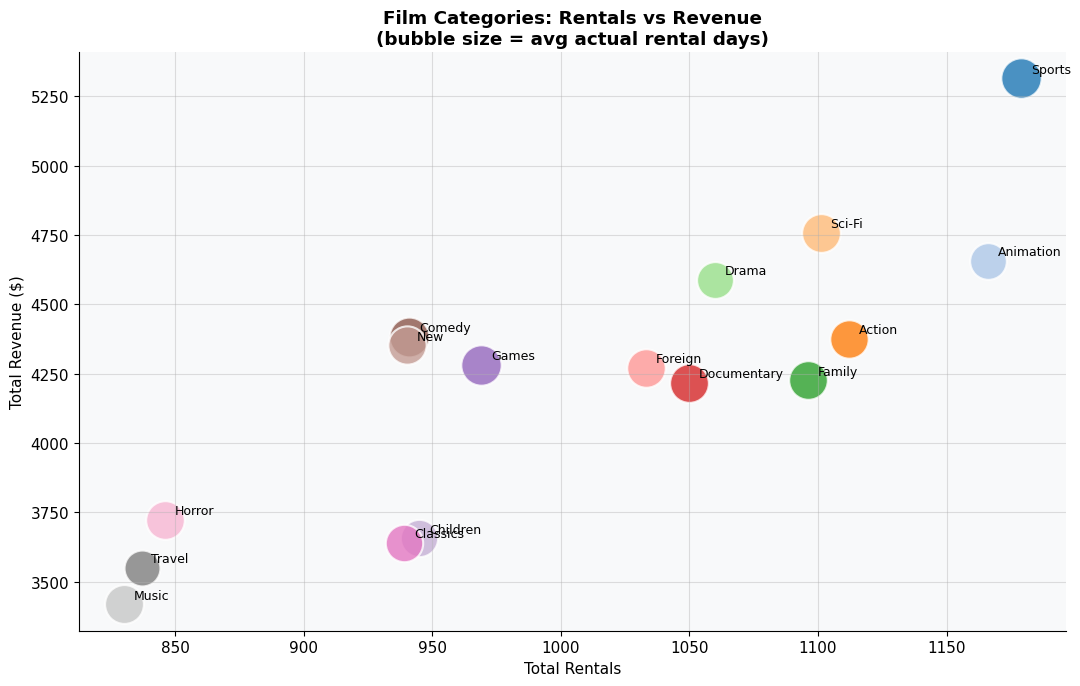

In [35]:
fig, ax = plt.subplots(figsize=(11, 7))

# Merge bq3 with bq9 avg duration for bubble size
import pandas as pd

bq3_merged = bq3.copy()

bq9_lookup = bq9.set_index("category")["avg_actual_days"]

bq3_merged["avg_days"] = (
    bq3_merged["category"]
    .map(bq9_lookup)
    .fillna(5)
    .astype(float)
)

colors = plt.cm.tab20.colors

for i, row in bq3_merged.iterrows():

    size = float((row["avg_days"] ** 3) * 6)

    ax.scatter(
        row["total_rentals"],
        row["total_revenue"],
        s=size,
        color=colors[i % 20],
        alpha=0.8,
        edgecolors="white",
        linewidth=1.5
    )

    ax.annotate(
        row["category"],
        (row["total_rentals"], row["total_revenue"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=9
    )

ax.set_xlabel("Total Rentals")
ax.set_ylabel("Total Revenue ($)")

ax.set_title(
    "Film Categories: Rentals vs Revenue\n(bubble size = avg actual rental days)",
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "viz2_categories.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### VIZ-3 · Monthly Rental Activity & Revenue Trend

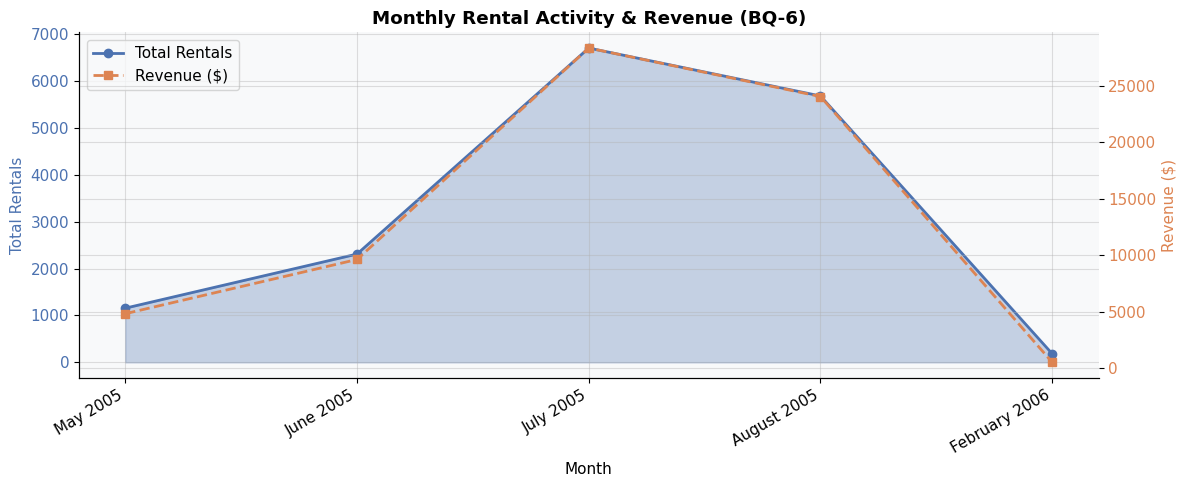

July 2005 is the peak month — ~6,700 rentals and $28k revenue.


In [27]:
fig, ax1 = plt.subplots(figsize=(12, 5))

labels = bq6["month_name"] + " " + bq6["year"].astype(str)
x = range(len(labels))

ax1.fill_between(x, bq6["total_rentals"], alpha=0.3, color=BLUE)
ax1.plot(x, bq6["total_rentals"], marker="o", color=BLUE, linewidth=2, label="Total Rentals")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Rentals", color=BLUE)
ax1.tick_params(axis="y", labelcolor=BLUE)
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=30, ha="right")

ax2 = ax1.twinx()
ax2.plot(x, bq6["total_revenue"], marker="s", color=ORANGE, linewidth=2,
         linestyle="--", label="Revenue ($)")
ax2.set_ylabel("Revenue ($)", color=ORANGE)
ax2.tick_params(axis="y", labelcolor=ORANGE)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Monthly Rental Activity & Revenue (BQ-6)", fontweight="bold")

plt.tight_layout()
plt.savefig("viz3_monthly.png", dpi=150, bbox_inches="tight")
plt.show()
print("July 2005 is the peak month — ~6,700 rentals and $28k revenue.")

### VIZ-4 · Late Return Rate — Top 10 Films

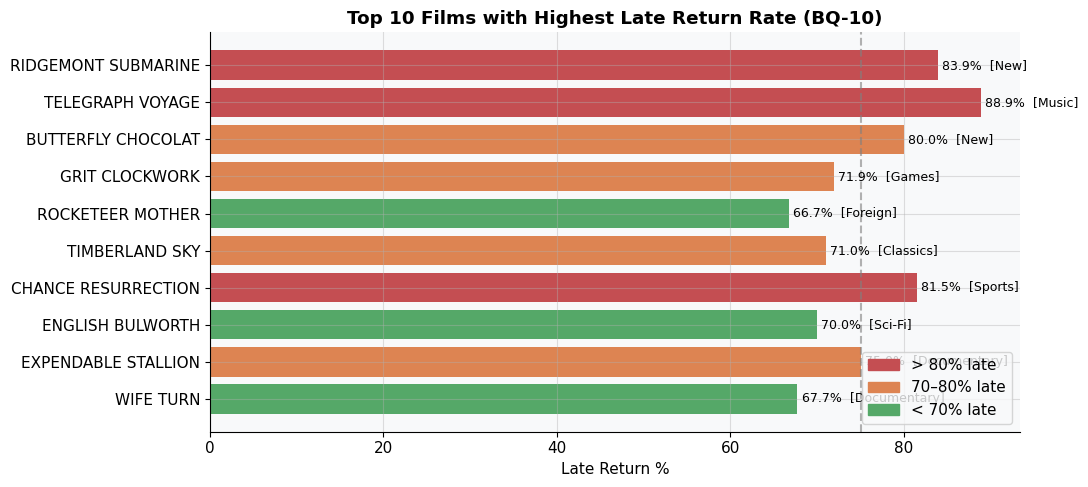

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))

# Convert Decimal column to float
bq10["late_pct"] = bq10["late_pct"].astype(float)

colors_late = [
    RED if p > 80 else ORANGE if p > 70 else GREEN
    for p in bq10["late_pct"]
]

bars = ax.barh(
    bq10["title"][::-1],
    bq10["late_pct"][::-1],
    color=colors_late[::-1]
)

ax.axvline(
    75,
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="75% threshold"
)

ax.set_xlabel("Late Return %")

ax.set_title(
    "Top 10 Films with Highest Late Return Rate (BQ-10)",
    fontweight="bold"
)

for i, (v, cat) in enumerate(
    zip(
        bq10["late_pct"][::-1],
        bq10["category"][::-1]
    )
):
    ax.text(
        float(v) + 0.5,
        i,
        f"{v:.1f}%  [{cat}]",
        va="center",
        fontsize=9
    )

red_p = mpatches.Patch(
    color=RED,
    label="> 80% late"
)

orange_p = mpatches.Patch(
    color=ORANGE,
    label="70–80% late"
)

green_p = mpatches.Patch(
    color=GREEN,
    label="< 70% late"
)

ax.legend(
    handles=[red_p, orange_p, green_p],
    loc="lower right"
)

plt.tight_layout()

plt.savefig(
    "viz4_late_returns.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### VIZ-5 · Quarterly Revenue Trend

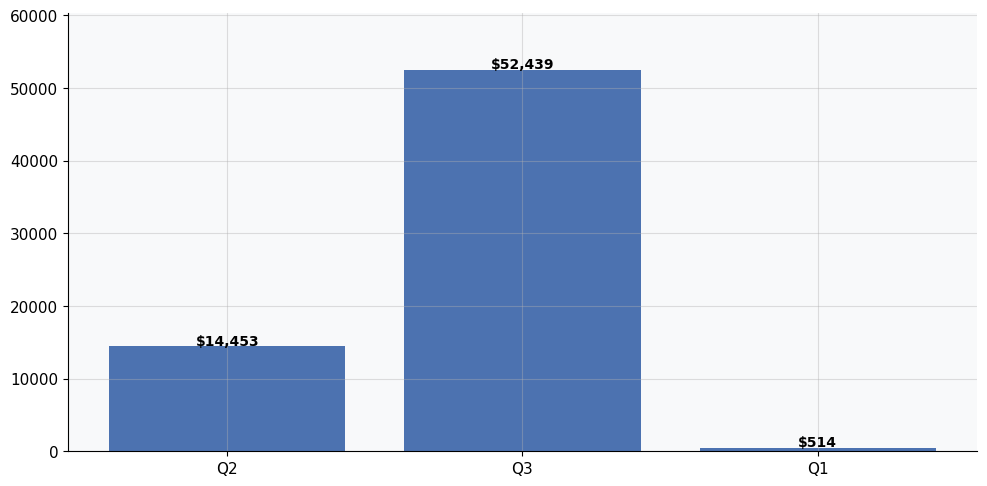

In [29]:
bq11["quarterly_revenue"] = bq11["quarterly_revenue"].astype(float)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    bq11["quarter"],
    bq11["quarterly_revenue"],
    color=BLUE
)

for bar, val in zip(bars, bq11["quarterly_revenue"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f"${val:,.0f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

ax.set_ylim(
    0,
    bq11["quarterly_revenue"].max() * 1.15
)

plt.tight_layout()
plt.savefig("viz5_quarterly.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. OLTP vs Data Warehouse — Query Execution Time Benchmark
We run **equivalent queries** on both `sakila` (OLTP) and `sakila_dw` (DW)  
and measure wall-clock execution time to demonstrate the performance advantage  
of the dimensional model for analytical workloads.

In [30]:
import time

def timed_query(conn, sql, runs=5):
    """Run a query `runs` times and return median elapsed seconds."""
    cursor = conn.cursor()
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        cursor.execute(sql)
        cursor.fetchall()
        times.append(time.perf_counter() - t0)
    cursor.close()
    return round(float(np.median(times)) * 1000, 2)   # ms

# Re-open connections (close them at end of section 5 — reopen here)
try:
    oltp_conn = get_connection(SOURCE_DB)
    dw_conn2  = get_connection(TARGET_DB)
    print("Connections re-opened for benchmark.")
except Exception as e:
    print(f"Could not connect: {e}. Run Section 1 first.")

Connections re-opened for benchmark.


In [31]:
# ── Benchmark query pairs ─────────────────────────────────────────
# Each tuple: (label, oltp_sql, dw_sql)

benchmark_queries = [

    ("BQ-1\nTop Rented Films",
     """
     SELECT f.title, cat.name AS category, COUNT(r.rental_id) AS total_rentals
     FROM   rental r
     JOIN   inventory     i   ON r.inventory_id  = i.inventory_id
     JOIN   film          f   ON i.film_id        = f.film_id
     JOIN   film_category fc  ON f.film_id        = fc.film_id
     JOIN   category      cat ON fc.category_id   = cat.category_id
     GROUP  BY f.film_id, f.title, cat.name
     ORDER  BY total_rentals DESC LIMIT 10
     """,
     """
     SELECT f.title, f.category, SUM(r.rental_count) AS total_rentals
     FROM   fact_rental r
     JOIN   dim_film    f ON r.film_key = f.film_key
     GROUP  BY f.film_key, f.title, f.category
     ORDER  BY total_rentals DESC LIMIT 10
     """),

    ("BQ-2\nFilm Revenue",
     """
     SELECT f.title, cat.name AS category,
            ROUND(SUM(p.amount), 2) AS total_revenue
     FROM   payment      p
     JOIN   rental       r   ON p.rental_id    = r.rental_id
     JOIN   inventory    i   ON r.inventory_id = i.inventory_id
     JOIN   film         f   ON i.film_id      = f.film_id
     JOIN   film_category fc ON f.film_id      = fc.film_id
     JOIN   category     cat ON fc.category_id = cat.category_id
     GROUP  BY f.film_id, f.title, cat.name
     ORDER  BY total_revenue DESC LIMIT 10
     """,
     """
     SELECT f.title, f.category,
            ROUND(SUM(p.payment_amount), 2) AS total_revenue
     FROM   fact_payment p
     JOIN   dim_film     f ON p.film_key = f.film_key
     WHERE  p.film_key IS NOT NULL
     GROUP  BY f.film_key, f.title, f.category
     ORDER  BY total_revenue DESC LIMIT 10
     """),

    ("BQ-3\nCategory Popularity",
     """
     SELECT cat.name AS category,
            COUNT(r.rental_id)      AS total_rentals,
            ROUND(SUM(p.amount), 2) AS total_revenue
     FROM   rental       r
     JOIN   inventory    i   ON r.inventory_id  = i.inventory_id
     JOIN   film         f   ON i.film_id        = f.film_id
     JOIN   film_category fc ON f.film_id        = fc.film_id
     JOIN   category     cat ON fc.category_id   = cat.category_id
     LEFT JOIN payment   p   ON r.rental_id      = p.rental_id
     GROUP  BY cat.category_id, cat.name
     ORDER  BY total_rentals DESC
     """,
     """
     SELECT f.category,
            SUM(r.rental_count)             AS total_rentals,
            ROUND(SUM(p.payment_amount), 2) AS total_revenue
     FROM   fact_rental   r
     JOIN   dim_film      f  ON r.film_key  = f.film_key
     LEFT JOIN fact_payment p ON r.rental_id = p.rental_id
     GROUP  BY f.category
     ORDER  BY total_rentals DESC
     """),

    ("BQ-6\nMonthly Trends",
     """
     SELECT YEAR(r.rental_date)  AS year,
            MONTH(r.rental_date) AS month_number,
            MONTHNAME(r.rental_date) AS month_name,
            COUNT(r.rental_id)       AS total_rentals,
            ROUND(SUM(p.amount), 2)  AS total_revenue
     FROM   rental r
     LEFT JOIN payment p ON r.rental_id = p.rental_id
     GROUP  BY year, month_number, month_name
     ORDER  BY year, month_number
     """,
     """
     SELECT d.year, d.month_name, d.month_number,
            SUM(r.rental_count)             AS total_rentals,
            ROUND(SUM(p.payment_amount), 2) AS total_revenue
     FROM   fact_rental   r
     JOIN   dim_date      d  ON r.rental_date_key = d.date_key
     LEFT JOIN fact_payment p ON r.rental_id      = p.rental_id
     GROUP  BY d.year, d.month_number, d.month_name
     ORDER  BY d.year, d.month_number
     """),

    ("BQ-10\nLate Returns",
     """
     SELECT f.title, cat.name AS category,
            COUNT(r.rental_id) AS total_rentals,
            SUM(CASE WHEN DATEDIFF(r.return_date, r.rental_date) > f.rental_duration
                     THEN 1 ELSE 0 END) AS late_returns
     FROM   rental       r
     JOIN   inventory    i   ON r.inventory_id  = i.inventory_id
     JOIN   film         f   ON i.film_id        = f.film_id
     JOIN   film_category fc ON f.film_id        = fc.film_id
     JOIN   category     cat ON fc.category_id   = cat.category_id
     WHERE  r.return_date IS NOT NULL
     GROUP  BY f.film_id, f.title, cat.name
     ORDER  BY late_returns DESC LIMIT 10
     """,
     """
     SELECT f.title, f.category,
            SUM(r.rental_count) AS total_rentals,
            SUM(CASE WHEN r.is_late_return = 1 THEN 1 ELSE 0 END) AS late_returns
     FROM   fact_rental r
     JOIN   dim_film    f ON r.film_key = f.film_key
     WHERE  r.return_date_key IS NOT NULL
     GROUP  BY f.film_key, f.title, f.category
     ORDER  BY late_returns DESC LIMIT 10
     """),
]

print(f"{'Query':<22} {'OLTP (ms)':>10} {'DW (ms)':>10} {'Speedup':>10}")
print("-" * 56)

results = []
for label, oltp_sql, dw_sql in benchmark_queries:
    oltp_ms = timed_query(oltp_conn, oltp_sql)
    dw_ms   = timed_query(dw_conn2,  dw_sql)
    speedup = round(oltp_ms / dw_ms, 1) if dw_ms > 0 else float("inf")
    results.append((label.replace("\n", " "), oltp_ms, dw_ms, speedup))
    short = label.replace("\n", " ")
    print(f"  {short:<20} {oltp_ms:>10.2f} {dw_ms:>10.2f} {speedup:>9.1f}x")

print("\nMedian over 5 runs each. Lower is better.")

Query                   OLTP (ms)    DW (ms)    Speedup
--------------------------------------------------------
  BQ-1 Top Rented Films      29.07      32.80       0.9x
  BQ-2 Film Revenue         64.33      43.08       1.5x
  BQ-3 Category Popularity      61.46      67.04       0.9x
  BQ-6 Monthly Trends       48.60      72.75       0.7x
  BQ-10 Late Returns        54.44      31.32       1.7x

Median over 5 runs each. Lower is better.


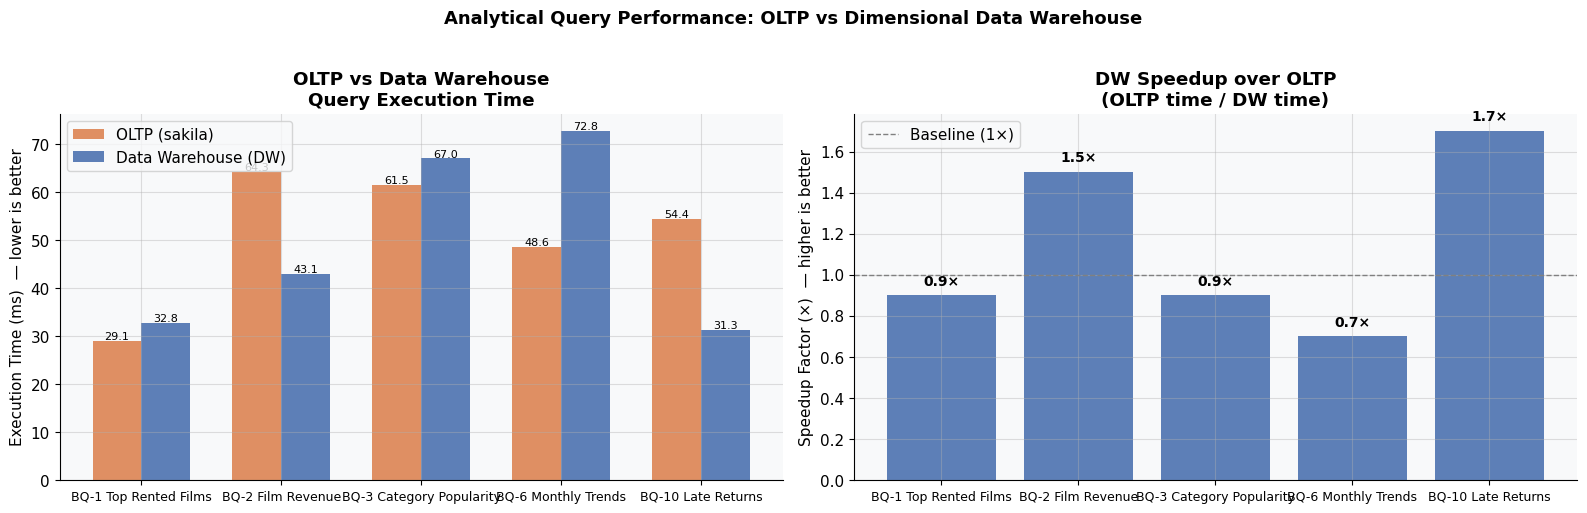


Key insight: The DW avoids expensive multi-table JOINs at query time.
Dimension denormalization and pre-computed measures reduce I/O significantly.


In [32]:
# ── Plot the benchmark results ─────────────────────────────────────

labels   = [r[0] for r in results]
oltp_ms  = [r[1] for r in results]
dw_ms    = [r[2] for r in results]
speedups = [r[3] for r in results]

x    = np.arange(len(labels))
w    = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar — OLTP vs DW
bars1 = ax1.bar(x - w/2, oltp_ms, w, label="OLTP (sakila)",      color=ORANGE, alpha=0.9)
bars2 = ax1.bar(x + w/2, dw_ms,   w, label="Data Warehouse (DW)", color=BLUE,   alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel("Execution Time (ms)  — lower is better")
ax1.set_title("OLTP vs Data Warehouse\nQuery Execution Time", fontweight="bold")
ax1.legend()
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3, f"{h:.1f}", ha="center", fontsize=8)

# Right: speedup factor
bar_colors = [GREEN if s >= 2 else BLUE for s in speedups]
ax2.bar(x, speedups, color=bar_colors, alpha=0.9)
ax2.axhline(1, color="gray", linestyle="--", linewidth=1, label="Baseline (1×)")
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Speedup Factor (×)  — higher is better")
ax2.set_title("DW Speedup over OLTP\n(OLTP time / DW time)", fontweight="bold")
ax2.legend()
for i, (bar, s) in enumerate(zip(ax2.containers[0], speedups)):
    ax2.text(i, s + 0.05, f"{s:.1f}×", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Analytical Query Performance: OLTP vs Dimensional Data Warehouse",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("viz_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey insight: The DW avoids expensive multi-table JOINs at query time.")
print("Dimension denormalization and pre-computed measures reduce I/O significantly.")

In [33]:
# ── Summary table ──────────────────────────────────────────────────
import pandas as pd

bench_df = pd.DataFrame(results, columns=["Query", "OLTP_ms", "DW_ms", "Speedup_x"])
bench_df["Time_Saved_ms"] = bench_df["OLTP_ms"] - bench_df["DW_ms"]
print("\n=== Benchmark Summary ===")
display(bench_df.style
    .format({"OLTP_ms": "{:.2f}", "DW_ms": "{:.2f}",
             "Speedup_x": "{:.1f}×", "Time_Saved_ms": "{:.2f}"})
    .background_gradient(subset=["Speedup_x"], cmap="Greens")
    .set_caption("Query Execution Time: OLTP vs Data Warehouse (median of 5 runs, in ms)"))

oltp_conn.close()
dw_conn2.close()
print("\nBenchmark connections closed.")


=== Benchmark Summary ===


,Query,OLTP_ms,DW_ms,Speedup_x,Time_Saved_ms
0,BQ-1 Top Rented Films,29.07,32.80,0.9×,-3.73
1,BQ-2 Film Revenue,64.33,43.08,1.5×,21.25
2,BQ-3 Category Popularity,61.46,67.04,0.9×,-5.58
3,BQ-6 Monthly Trends,48.60,72.75,0.7×,-24.15
4,BQ-10 Late Returns,54.44,31.32,1.7×,23.12



Benchmark connections closed.
